# Centroids, Medoids, and Exemplars

PLSCAN can efficiently compute cluster centers either as average feature
coordinates (centroid), most central data points (medoid), or by finding the
most dense data points (exemplars).

First, lets load the data again.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (2.75, 0.618 * 2.75)

data = np.load("data/clusterable/sources/clusterable_data.npy")

The sklearn estimator ``PLSCAN`` has member-functions to compute centroids,
medoids and exemplars.

In [2]:
from fast_plscan import PLSCAN

c = PLSCAN(min_samples=10).fit(data)
centroids = c.compute_centroids()
medoids = data[c.compute_medoid_indices(), :]
exemplars = [data[indices, :] for indices in c.compute_exemplar_indices()]

Centroids and medoids tend to be similar on Euclidean distances. For other
distance methods, medoids are more appropriate. Exemplars provide more detail  
about a cluster's shape. As a result, they are used to cross-cluster membership  
probabilities in the ``fast_plscan.prediction`` module.

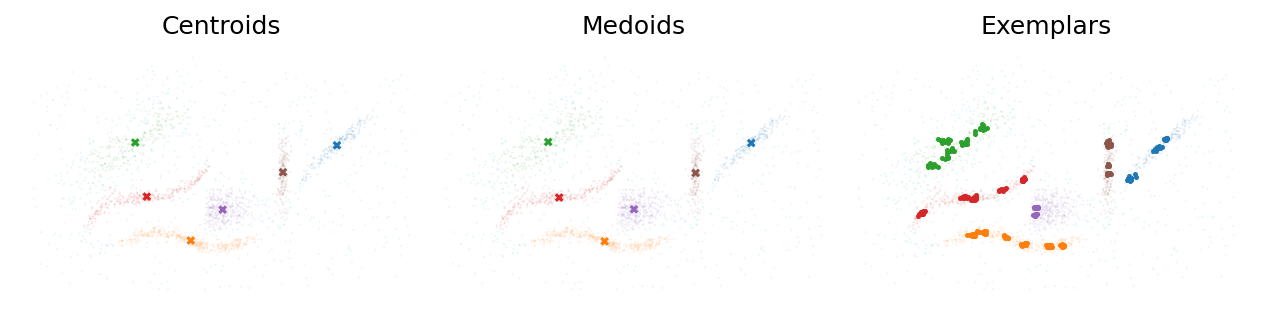

In [3]:
plt.figure(figsize=(3 * 2.75, 0.618 * 2.75))
plt.subplot(1, 3, 1)
plt.scatter(*data.T, c=c.labels_ % 10, s=1, linewidth=0, cmap="tab10", alpha=0.1)
plt.scatter(
    *centroids.T, c=np.arange(len(centroids)), s=10, marker="x", cmap="tab10", vmax=9
)
plt.title("Centroids")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.scatter(*data.T, c=c.labels_ % 10, s=1, linewidth=0, cmap="tab10", alpha=0.1)
plt.scatter(
    *medoids.T, c=np.arange(len(medoids)), s=10, marker="x", cmap="tab10", vmax=9
)
plt.title("Medoids")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.scatter(*data.T, c=c.labels_ % 10, s=1, linewidth=0, cmap="tab10", alpha=0.1)
for i, explrs in enumerate(exemplars):
    plt.scatter(*explrs.T, color=f"C{i}", s=2)
plt.title("Exemplars")
plt.axis("off")

plt.subplots_adjust(0, 0, 1, 1, 0, 0)
plt.show()